# K-Means Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('./data/UCI_Credit_Card.csv')
display(df.head())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [2]:
target_col = 'default.payment.next.month'

X = df.drop(columns=['ID', target_col])
X = pd.get_dummies(X, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape after preprocessing: {X_scaled.shape}")

Shape after preprocessing: (30000, 30)


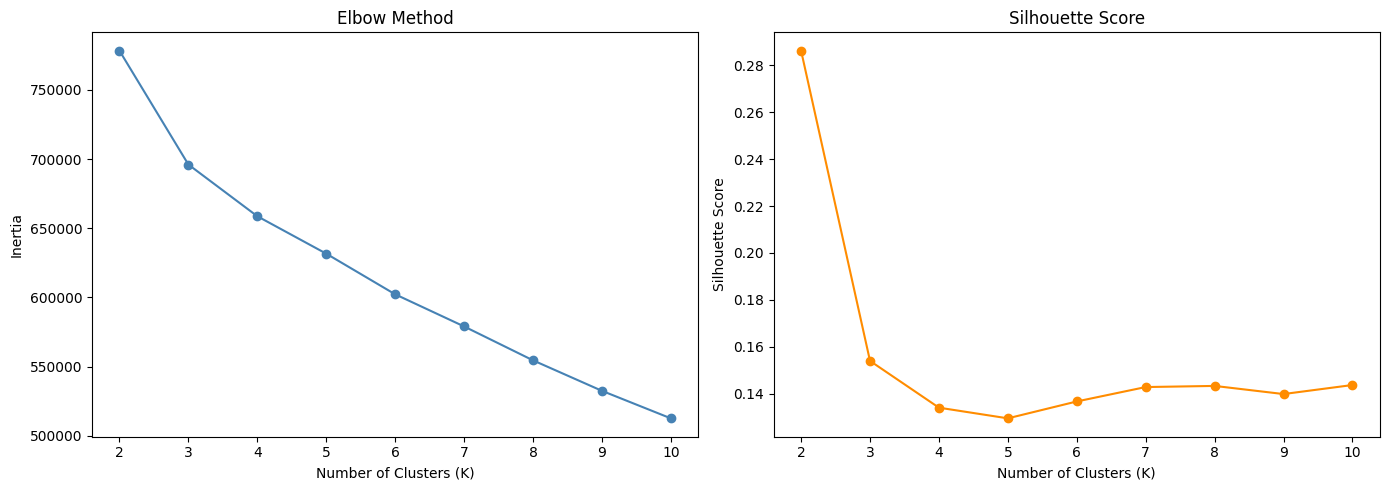

Best K (highest silhouette): 2


In [3]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouette_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(silhouette_scores)]
print(f"Best K (highest silhouette): {best_k}")

In [4]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print(f"Silhouette Score (K={best_k}): {silhouette_score(X_scaled, cluster_labels, sample_size=5000, random_state=42):.4f}")
print(f"\nCluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Silhouette Score (K=2): 0.2863

Cluster sizes:
0     4655
1    25345
Name: count, dtype: int64


Variance explained by 2 components: 35.78%


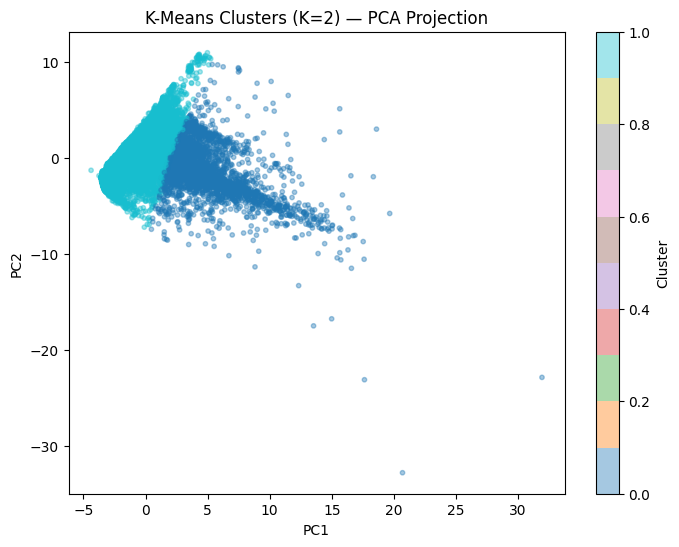

In [5]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.4, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means Clusters (K={best_k}) — PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

Cluster Profiles (mean values):


,LIMIT_BAL,AGE,PAY_0,BILL_AMT1,PAY_AMT1,default.payment.next.month
Cluster,,,,,,
0,259821.20,36.78,0.35,179565.60,14420.91,0.21
1,150525.23,35.25,-0.08,27651.29,4055.16,0.22


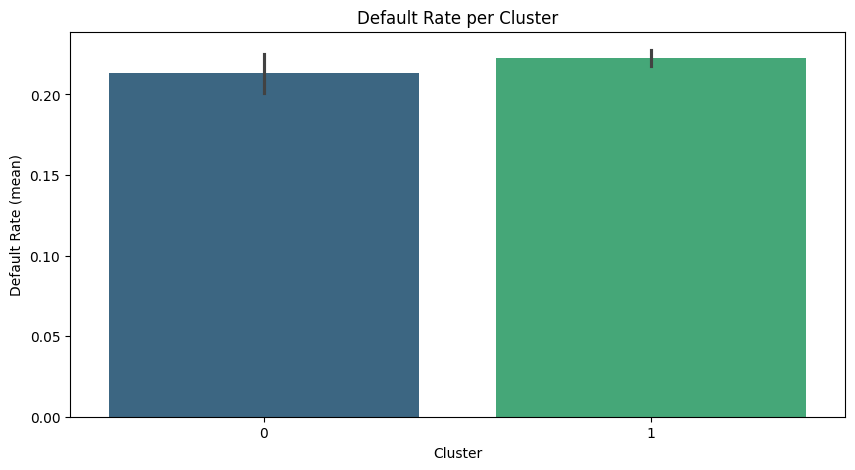

In [6]:
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

profile_cols = ['LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'PAY_AMT1', target_col]
cluster_profile = df_clustered.groupby('Cluster')[profile_cols].mean().round(2)

print("Cluster Profiles (mean values):")
display(cluster_profile)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_clustered, x='Cluster', y=target_col, palette='viridis')
plt.title('Default Rate per Cluster')
plt.ylabel('Default Rate (mean)')
plt.xlabel('Cluster')
plt.show()